# Sales Data Analysis using Pandas and SQL

This project analyzes customer orders, sales trends, customer segments, and product performance using Python, Pandas, Matplotlib, Seaborn, and SQLite.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## Loading Dataset

In [32]:
df = pd.read_csv("../Data/Sample - Superstore.csv", encoding="latin1")

In [33]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Audit

Checking:
- shape
- columns
- datatypes
- missing values
- duplicates

In [34]:
df.shape

(9994, 21)

In [35]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [37]:
df.columns = df.columns.str.lower()

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row id         9994 non-null   int64  
 1   order id       9994 non-null   str    
 2   order date     9994 non-null   str    
 3   ship date      9994 non-null   str    
 4   ship mode      9994 non-null   str    
 5   customer id    9994 non-null   str    
 6   customer name  9994 non-null   str    
 7   segment        9994 non-null   str    
 8   country        9994 non-null   str    
 9   city           9994 non-null   str    
 10  state          9994 non-null   str    
 11  postal code    9994 non-null   int64  
 12  region         9994 non-null   str    
 13  product id     9994 non-null   str    
 14  category       9994 non-null   str    
 15  sub-category   9994 non-null   str    
 16  product name   9994 non-null   str    
 17  sales          9994 non-null   float64
 18  quantity       9994

In [39]:
df.columns = df.columns.str.replace(" ", "_")

In [40]:
df.isnull().sum()


row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64

In [41]:
print(df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='str')


In [42]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

In [43]:
df.columns = df.columns.str.lower()

In [44]:
df.drop_duplicates(inplace=True)

In [20]:
df.fillna(0, inplace=True)

,row id,order id,order date,ship date,ship mode,customer id,customer name,segment,country,city,...,postal code,region,product id,category,sub-category,product name,sales,quantity,discount,profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [45]:
df["order_date"] = pd.to_datetime(df["order_date"])

## GroupBy Analysis

In [46]:
region_sales = df.groupby("region")["sales"].sum()

region_sales

region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: sales, dtype: float64

In [47]:
category_sales = df.groupby("category")["sales"].sum()

category_sales

category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: sales, dtype: float64

In [49]:
multi_group = df.groupby(["region", "segment"])["sales"].sum()

multi_group

region   segment    
Central  Consumer       252031.4340
         Corporate      157995.8128
         Home Office     91212.6440
East     Consumer       350908.1670
         Corporate      200409.3470
         Home Office    127463.7260
South    Consumer       195580.9710
         Corporate      121885.9325
         Home Office     74255.0015
West     Consumer       362880.7730
         Corporate      225855.2745
         Home Office    136721.7770
Name: sales, dtype: float64

## Business Metrics

In [50]:
total_revenue = df["sales"].sum()

total_revenue

np.float64(2297200.8603)

In [51]:
avg_order = df["sales"].mean()

avg_order

np.float64(229.85800083049827)

In [52]:
top_products = df.groupby("product_name")["sales"].sum().sort_values(ascending=False)

top_products.head()

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: sales, dtype: float64

## Pivot Tables

In [53]:
pivot1 = pd.pivot_table(
    df,
    values="sales",
    index="region",
    columns="category",
    aggfunc="sum"
)

pivot1

category,Furniture,Office Supplies,Technology
region,,,
Central,163797.1638,167026.415,170416.312
East,208291.2040,205516.055,264973.981
South,117298.6840,125651.313,148771.908
West,252612.7435,220853.249,251991.832


## Histogram visualization

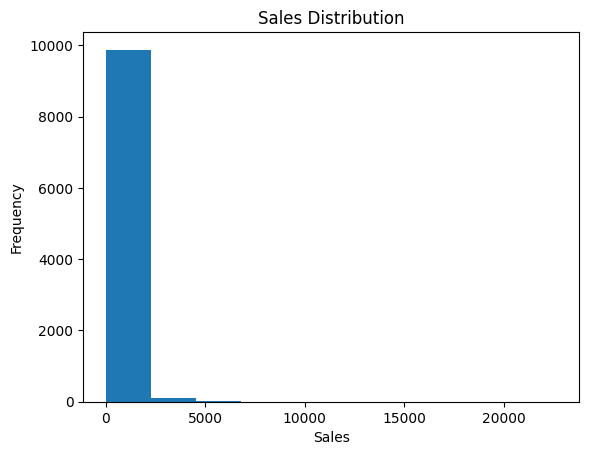

In [54]:
plt.hist(df["sales"])
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

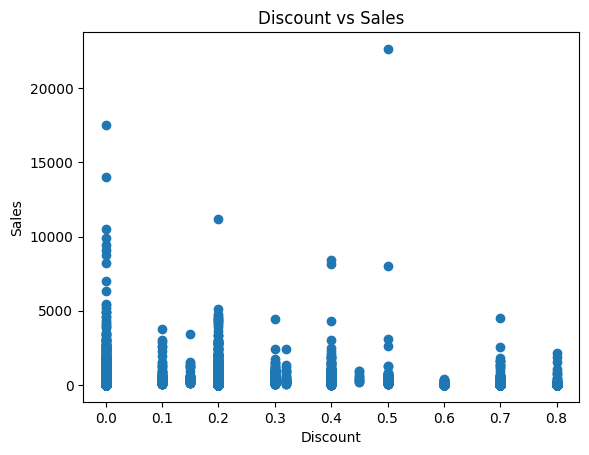

In [55]:
plt.scatter(df["discount"], df["sales"])
plt.xlabel("Discount")
plt.ylabel("Sales")
plt.title("Discount vs Sales")
plt.show()

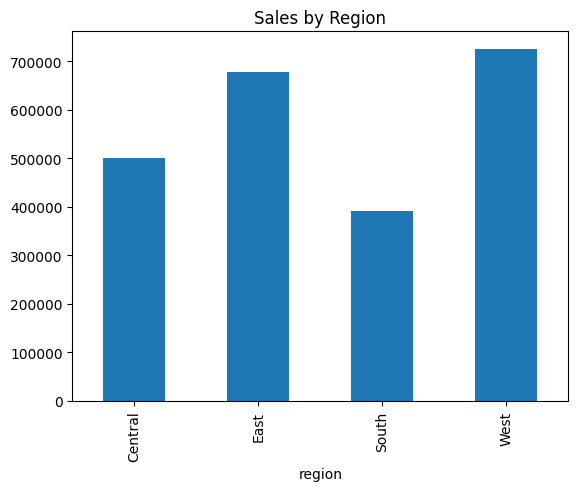

In [56]:
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.show()

In [57]:
df["month"] = df["order_date"].dt.month

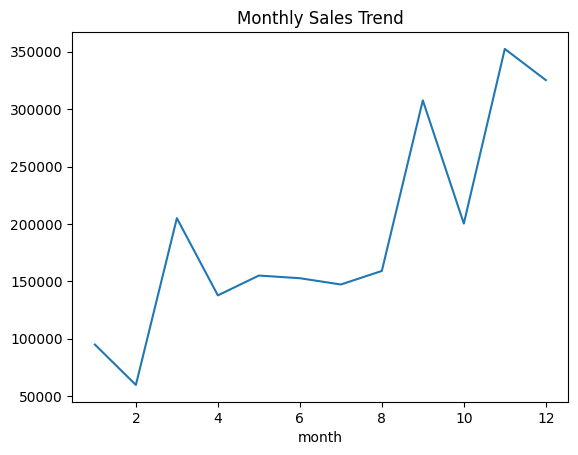

In [58]:
monthly_sales = df.groupby("month")["sales"].sum()

monthly_sales.plot(kind="line")
plt.title("Monthly Sales Trend")
plt.show()

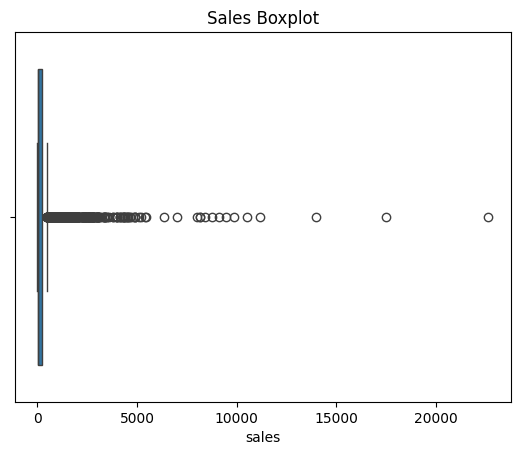

In [59]:
sns.boxplot(x=df["sales"])
plt.title("Sales Boxplot")
plt.show()

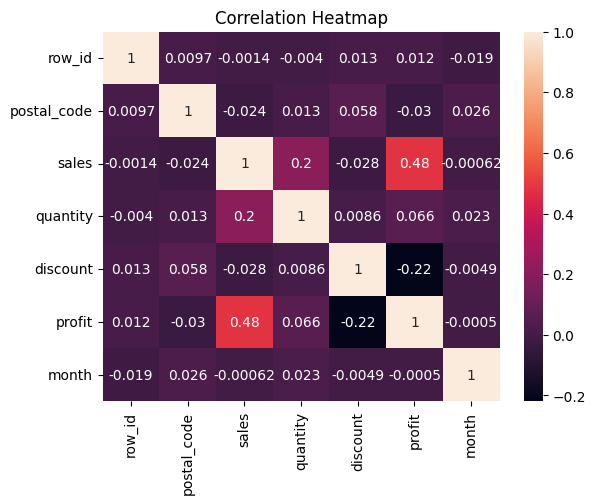

In [60]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Business Insights

1. West region generated the highest revenue.

2. Technology category performed best.

3. Discounts do not always increase sales.

4. Monthly sales fluctuate across the year.

# Pandas vs SQL Comparison

| Task | Pandas | SQL |
|---|---|---|
| Filtering | Easy | Structured |
| Grouping | groupby() | GROUP BY |
| Joins | merge() | JOIN |
| Aggregation | agg() | SUM(), AVG() |
| Visualization | Direct plotting | External tools needed |

In [61]:
plt.savefig("../visuals/histogram.png")

<Figure size 640x480 with 0 Axes>

In [62]:
plt.savefig("../visuals/heatmap.png")

<Figure size 640x480 with 0 Axes>

In [63]:
plt.savefig("../visuals/bar_chart.png")

<Figure size 640x480 with 0 Axes>